# Aufgaben

In [1]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_blobs, load_digits, load_iris
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

## Quiz-Section

## WarmUp
<div>
    <img src=attachment:1d58fba3-dd18-4609-a776-6e3d77859818.png width=100>
</div>
Let's do stretching: Kleinstaufgaben, um die gelernten Funktionen einzuüben.
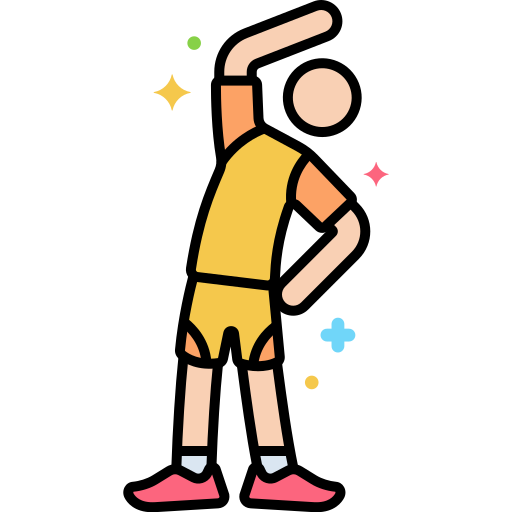

## Aufgabe: Explore SVM and Random Forest

<div>
    <img src=attachment:dbaf54bf-14b3-4352-8792-ec605bd32349.png width=300>
</div>

Schreiben Sie eine Funktion, die Ihnen an einem gegebenen Datensatz als Eingabeargumente `X` und `y` sowohl einen Random Forest Classifier, als auch eine SVM trainiert. Wir begnügen uns hier wieder mit einem simplen Training am Train-Split mit den Default-Hyperparameterwerten der Klassifikatoren. Die Funktion soll zusätzlich als Eingabeargument `list_of_noise_levels` eine Liste an Werten aufnehmen, die den Verrauschungsgrad der Daten abbilden sollen. Jeder Wert aus dieser Liste soll genutzt werden, um die Spalten der Feature-Matrix `X` mit Gauß'schem Rauschen zu versehen. Die Ausprägung des Rauschens soll `noise_level`-mal der Standardabweichung aller Daten in `X` entsprechen. Die Funktion soll also die Trainings Ihrer Klassifikatoren für jedes Rauschlevel durchführen und den Test-Score je Klassifikator als Liste zurückgeben. Visualisieren Sie sich im Anschluss die beiden Listen (s. Abbildung). Wie gehen unsere beiden Klassifikatoren mit Rauschen um?
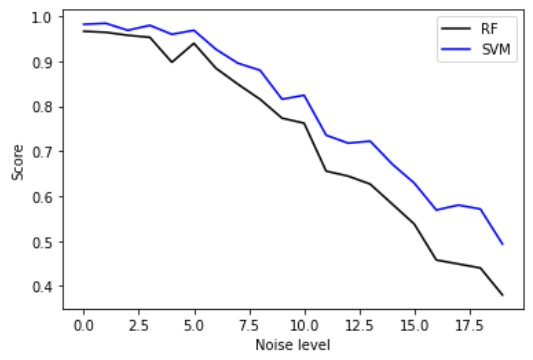

In [2]:
# Data set 1
#X, y = make_blobs(n_samples=300, centers=2)

# Data set 2: iris
#X, y = load_iris(return_X_y=True)

# Data set 3: digits
#X, y = load_digits(return_X_y=True)

def explore_noise_behavior(X, y, list_of_noise_levels):
    """

    """

        # Add noise

        # Train test split

        # Our models

        # Get scores


### Lösung

In [2]:
list_of_noise_levels = np.arange(0.1, 2.1, 0.1)

# Data set 1
#X, y = make_blobs(n_samples=300, centers=2)

# Data set 2: iris
#X, y = load_iris(return_X_y=True)

# Data set 3: digits
X, y = load_digits(return_X_y=True)

def explore_noise_behavior(X, y, list_of_noise_levels):
    """

    """
    list_of_rf_scores = []
    list_of_svc_scores = []
    for noise_level in list_of_noise_levels:

        # Add noise
        print(f'Working on noise_level {noise_level}')
        std_X = X.std()
        X_noise = X + np.random.normal(loc=0, scale=noise_level*std_X, size=X.shape)

        # Train test split
        Xtrain, Xtest, ytrain, ytest = train_test_split(X_noise, y)

        # Our models
        rf = RandomForestClassifier().fit(Xtrain, ytrain)
        svc = SVC().fit(Xtrain, ytrain)

        # Get scores
        list_of_rf_scores.append(rf.score(Xtest, ytest))
        list_of_svc_scores.append(svc.score(Xtest, ytest))
        
    return list_of_rf_scores, list_of_svc_scores


In [3]:
list_of_rf_scores, list_of_svc_scores = explore_noise_behavior(X, y, list_of_noise_levels)

Working on noise_level 0.1
Working on noise_level 0.2
Working on noise_level 0.30000000000000004
Working on noise_level 0.4
Working on noise_level 0.5
Working on noise_level 0.6
Working on noise_level 0.7000000000000001
Working on noise_level 0.8
Working on noise_level 0.9
Working on noise_level 1.0
Working on noise_level 1.1
Working on noise_level 1.2000000000000002
Working on noise_level 1.3000000000000003
Working on noise_level 1.4000000000000001
Working on noise_level 1.5000000000000002
Working on noise_level 1.6
Working on noise_level 1.7000000000000002
Working on noise_level 1.8000000000000003
Working on noise_level 1.9000000000000001
Working on noise_level 2.0


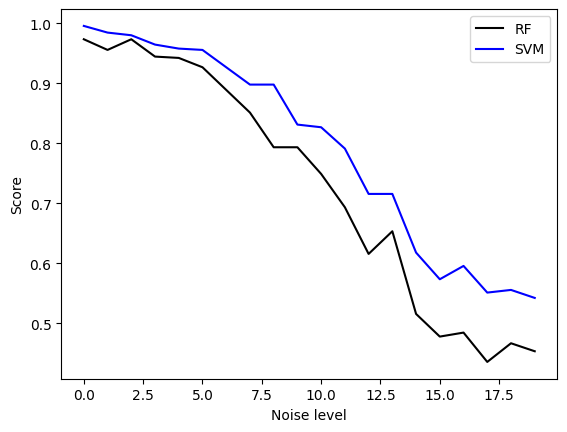

In [4]:
plt.plot(list_of_rf_scores, color='black')
plt.plot(list_of_svc_scores, color='blue')
plt.legend(['RF', 'SVM'])
plt.xlabel('Noise level')
plt.ylabel('Score');

## Aufgabe: Worauf konzentriert sich mein Model?

<div>
    <img src=attachment:8987a803-bb27-4788-8222-2a5cd4d75c0b.png width=200>
</div>

Nutzen Sie den OpenML-Fetcher `fetch_openml`, um verschiedene Datensätze aus der OpenML-Platform (https://www.openml.org/) zu laden - den Digits-Datensatz in einer höheren Auflösung `mnist_784`und den Fashion-MNIST Datensatz von Zalando-Research `fashion-mnist`. Nutzen Sie Ihr wissen, um zu bestimmen, auf welche Bereiche der Bilder sich ein `RandomForestClassifier` am stärksten konzentriert, um seine Klassifikationen durchzuführen bzw. worauf seine Aufmerksamkeit am stärksten liegt (Grid- oder Random-Search wollen wir hier nicht ausführen - uns reicht für diese Aufgabe wieder ein simples Training am Trainingsdatensatz). Hierzu haben Sie in der Vorlesung die `permutation_importance` kennengelernt. Googlen Sie nach dem `RandomForestClassifier`: gibt es ein Pendant zur `permutation_importance`, das Ihnen der Klassifikator schon mitliefert? Visualisieren Sie sich Ihr Ergebnis so wie oben in der Abbildung angegeben. Schreiben Sie sich hierzu eine Funktion `attention_of_my_model`, die Ihnen ein Bild wie oben plottet und das zugehörige Array ausgibt. Die Eingabeargumente sollen `string_of_dataset` und `shape_of_images` sein. Ersteres entspricht dem String des jeweiligen Datensatzes der OpenML-Plattform und Letzteres der Shape der zugrundeliegenden Bilder.

Untersuchen Sie die Visualisierung mittels Schwellwerten: welche Bereiche liegen unter-, welche oberhalb eines bestimmten Schwellwertes? Für was könnten Sie diese Herangehensweise verwenden (denken Sie an das Feature-Engineering).

Orientieren Sie sich für die Arbeitsschritte an den Kommentaren.

Welche Datensätze finden Sie auf OpenML noch, die diese Funktion verarbeiten könnte?
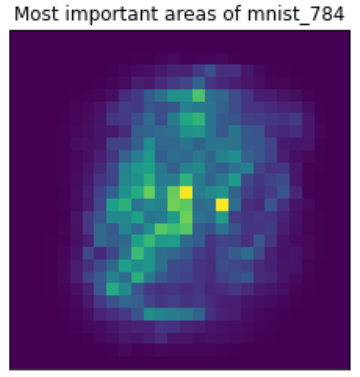

In [6]:
# Import
from sklearn.datasets import fetch_openml

def where_does_my_model_look(string_of_dataset, shape_of_images):
    """
    
    """
    
    # Get data
    
    # Train random forest without sweep

    # Attention of model


In [7]:
# Show histogram of feature importances


In [8]:
# Show image of thresholded feature importances


### Lösung

In [5]:
# Import
from sklearn.datasets import fetch_openml

def where_does_my_model_look(string_of_dataset, shape_of_images):
    """
    
    """
    
    # Get data
    X, y = fetch_openml(name=string_of_dataset, return_X_y=True, parser='auto', cache=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    
    # Train random forest without sweep
    model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
    model.fit(X_train, y_train)

    # Attention of model
    feature_importances = model.feature_importances_
    plt.imshow(feature_importances.reshape(shape_of_images))
    plt.title(f'Most important areas of {string_of_dataset}')
    plt.xticks([])
    plt.yticks([])
    
    return feature_importances

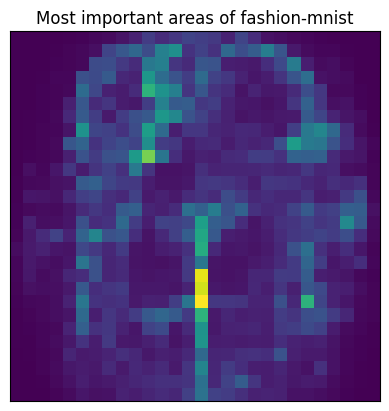

In [6]:
feature_importances = where_does_my_model_look('fashion-mnist', (28, 28))

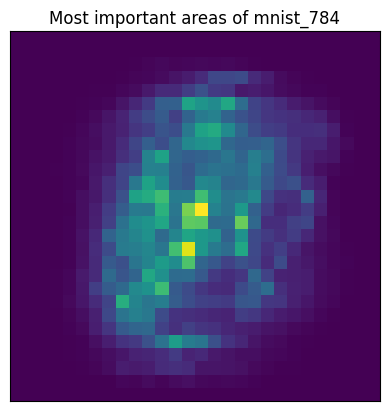

In [7]:
feature_importances = where_does_my_model_look('mnist_784', (28, 28))

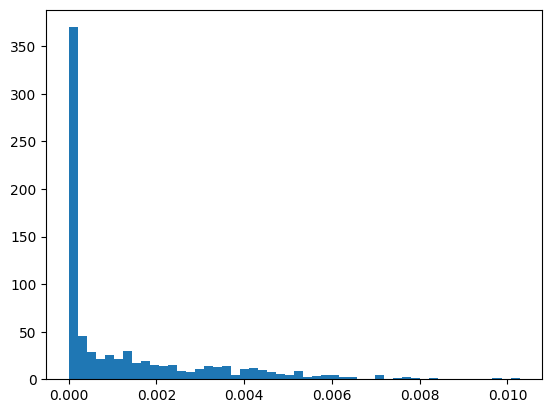

In [8]:
# Show histogram of feature importances
plt.hist(feature_importances, bins=50);

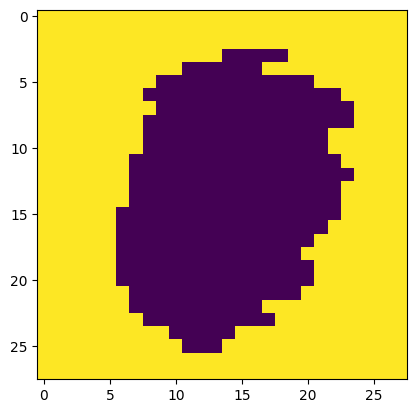

In [9]:
# Show image of thresholded feature importances
plt.imshow(feature_importances.reshape((28, 28)) <= 0.001);

## Aufgabe: How to teach a machine to recognize Music

<div>
    <img src=attachment:2448a276-622e-4db7-997f-61c913d70d21.png width=80>
</div>

Stellen Sie sich vor Sie würden bei einem großen Musik-Streaming-Dienst arbeiten. Ihnen liegen von sehr vielen Songs _Audio-Features_ (https://developer.spotify.com/discover/) und die jeweiligen _Genres_, denen die Songs angehören, vor. Ihre Aufgabe ist es nun herauszufinden, ob es möglich ist anhand dieser Features ein Machine Learning Modell zu trainieren, das die vorliegenden Songs zuverlässig in Genres klassifizieren kann. 

Wir beschränken uns auf zwei kleinere (je 5000 Songs) Datensätze. Bei diesen Datensätzen hat jemand 30s-Song-Schnipsel _gescraped_ - und zwar von 5 und 10 spezifischen Genres. Mal sehen, ob es sich hierbei um Genres handelt, die ein Klassifikator gut trennen kann.

* Fangen Sie zuerst mit dem Datensatz `spotify_data_five_genres.csv` an:
    * Schauen Sie sich die Daten an: welche Spalten sind für uns irrelevant? Visualisieren Sie die Unterschiede der einzelnen Genres bzgl. der Audio-Features. Wie können Sie einen Repräsentanten für jedes Genre berechnen?
    * Nutzen Sie einen `RandomForestClassifier` und eine `SVC` und trainieren Sie diese auf den Datensatz. Welche Vorhersagegenauigkeit können Sie erreichen? Wie schneiden beide Klassifikatoren im Vergleich ab?
    * Welches Audio-Feature ist für die Vorhersage am _wichtigsten_?
* Nun nehmen wir doppelt so viele Genres - machen Sie nun mit dem Datensatz `spotify_data_ten_genres.csv` weiter:
    * Wiederholen Sie die obigen Schritte. Auf welche Vorhersagegenauigkeit kommen Sie jetzt?
    * Denken Sie, dass 10 Genres überhaupt ausreichend sind, um die vorliegenden 5000 Songs einzugruppieren? Wie könnten Sie das überprüfen?

__Bonus__: Schauen Sie sich mal die _Spotify API_ an. Sie selbst können von jedem Song diese Audio-Features abgreifen!

__Challenge__: Können Sie Ihr Hörverhalten in diesem Feature-Raum visualisieren? :)
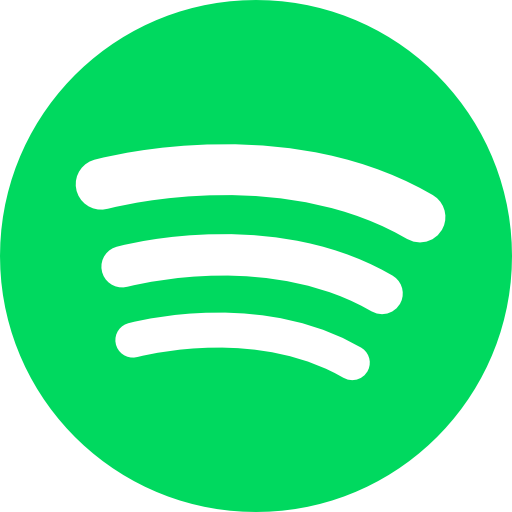

### Lösung

#### Five Generes Dataset

In [10]:
# Get data
songs = pd.read_csv('./../res/data/spotify_data_ten_genres.csv')

In [11]:
# Too much information
songs.head(1)

,id,genre,track_name,preview_url,location,filename,artist,artist_uri,album,release_date,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1Gd0GJF72EJiPFFJYSeDO9,baroque,"Violin Concerto in E Major, BWV 1042: III. All...",https://p.scdn.co/mp3-preview/a995fcef83acf3e4...,"./scrapes/baroque/Violin Concerto in E Major, ...","Violin Concerto in E Major, BWV 1042: III. All...",Johann Sebastian Bach,spotify:artist:5aIqB5nVVvmFsvSdExz408,Bach: Works for Violin,2014-09-26,...,0.394,4,-10.845,1,0.0409,0.807,0.000094,0.0826,0.762,103.523


In [12]:
# Get X and y
X = songs._get_numeric_data().drop(columns=['key', 'mode'])
y = songs['genre']

# Representative of genres
X[X.columns] = StandardScaler().fit_transform(X)
df = pd.concat([X, y], axis=1)
df_grouped = df.groupby('genre').mean()
df_grouped

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
genre,,,,,,,,,
baroque,-0.802733,-1.070964,-0.953213,-0.471324,1.143794,0.629968,-0.151119,0.076610,-0.193050
classical,-1.061155,-1.233478,-1.288104,-0.411171,1.261132,0.865382,-0.126798,-0.642755,-0.376267
hip hop,0.890327,0.494593,0.638794,0.863391,-0.736853,-0.482373,0.036664,0.374744,0.074705
pop,0.485701,0.572093,0.664716,0.080222,-0.608755,-0.479762,-0.053930,0.123355,-0.020771
progressive bluegrass,-0.156171,0.071051,0.185530,-0.553853,0.413029,0.331004,0.143588,0.653777,0.311614
r&b,0.553059,0.359977,0.606688,0.264754,-0.552659,-0.503400,-0.043408,0.326699,-0.034357
rap,0.954003,0.455537,0.614038,1.113390,-0.758648,-0.503786,-0.026623,0.051577,0.249502
rock,-0.394104,0.860958,0.456085,-0.253603,-0.718226,-0.305295,0.097636,0.246994,0.274523
serialism,-1.097147,-1.411942,-1.613620,-0.371045,1.329457,0.644781,0.058901,-1.212867,-0.375768


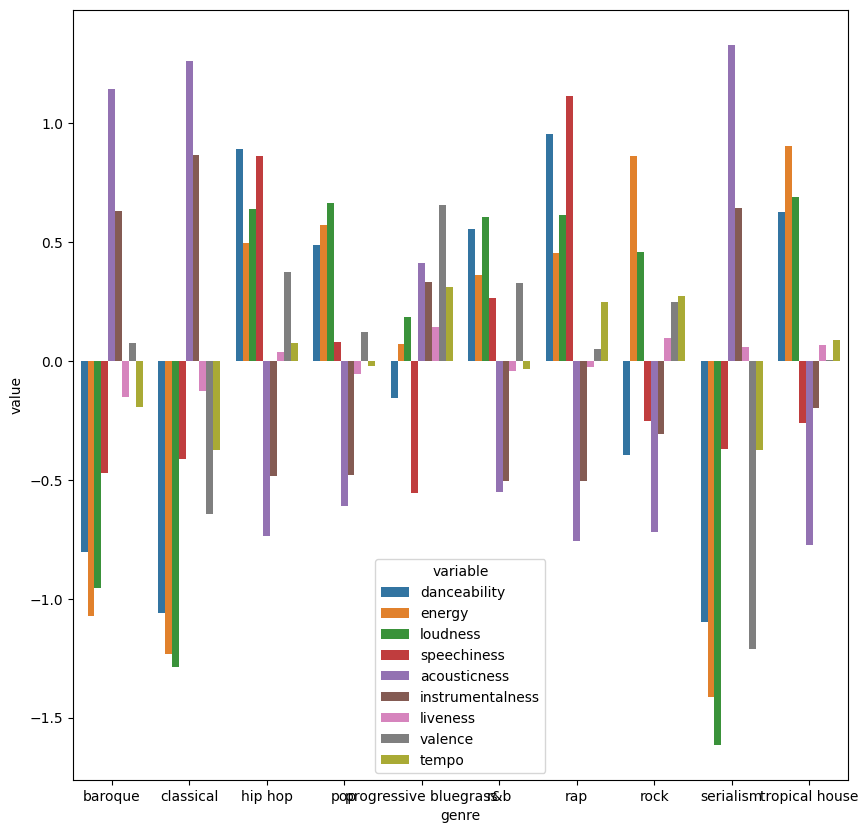

In [13]:
# Bar plot of representatives
fig, ax = plt.subplots(figsize=(10,10))
df_grouped.reset_index(inplace=True)
df_grouped_melt = df_grouped.melt(id_vars=['genre'])
sns.barplot(x='genre', y='value', hue='variable', data=df_grouped_melt, ax=ax);

#### Random Forest

In [14]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Train primitive model
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

# Look at the scores
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.8818666666666667
0.5816


In [15]:
# Look at cross validation score
np.mean(cross_val_score(model, X_train, y_train))

np.float64(0.5751999999999999)

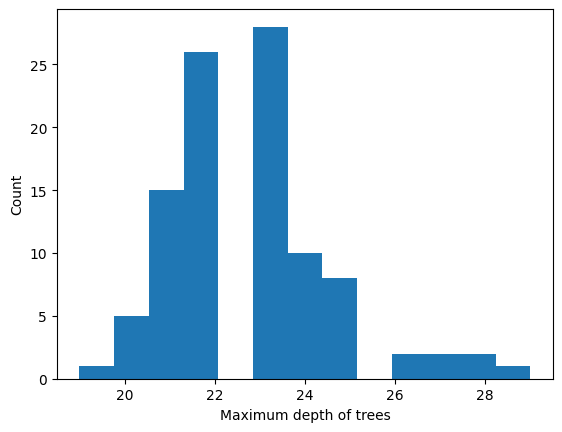

In [16]:
# Plot histogram of maximum depth of trees in forest
max_depths = np.array([estimator_.tree_.max_depth for estimator_ in model.estimators_])
plt.hist(max_depths, bins=13)
plt.xlabel('Maximum depth of trees')
plt.ylabel('Count');

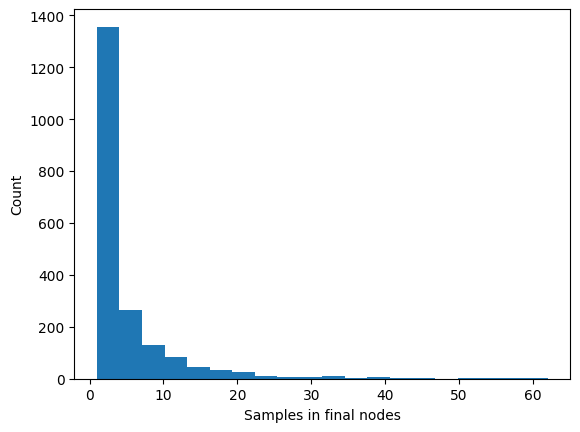

In [17]:
# Investigate number of samples in final nodes: all trees
n_node_samples = np.array([estimator_.tree_.n_node_samples[-20:] for estimator_ in model.estimators_])
plt.hist(n_node_samples.flat, bins=20)
plt.xlabel('Samples in final nodes')
plt.ylabel('Count');

In [18]:
# Parameter ranges
list_max_depth = [None] + list(range(3, 18, 1))
list_min_samples_leaf = list(range(5, 20, 2))

# Parameters dict
parameters = {
    'max_depth': list_max_depth,
    'min_samples_leaf': list_min_samples_leaf,
}

In [19]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Random search
rs = RandomizedSearchCV(RandomForestClassifier(n_estimators=100), 
                        parameters, 
                        verbose=2, 
                        cv=4,
                        n_iter=200, 
                        n_jobs=-1
                        )  
rs.fit(X_train, y_train)

# Best model
model = rs.best_estimator_
model.fit(X_train, y_train)

# Look at the scores
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

C:\Users\gom39655\AppData\Local\anaconda3\envs\KS_new\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 128 is smaller than n_iter=200. Running 128 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 4 folds for each of 128 candidates, totalling 512 fits
0.8202666666666667
0.5728


<Axes: >

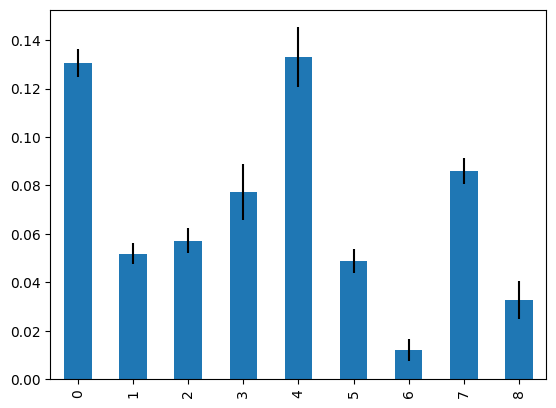

In [20]:
# What audio feature is most important concerning genere classification
importances = permutation_importance(model, X_test, y_test)
s = pd.Series(importances['importances_mean'])
s.plot.bar(yerr=importances['importances_std'])

In [26]:
# Save
import joblib
np.save('C:/Users/gom39655/sync/code/git/teaching/lectures/03_wise_2021_22/predictive-maintenance/notebooks/examples/evaluation-confusion-matrix-roc/data/spotify_rf_ytest.npy', y_test.values)
np.save('C:/Users/gom39655/sync/code/git/teaching/lectures/03_wise_2021_22/predictive-maintenance/notebooks/examples/evaluation-confusion-matrix-roc/data/spotify_rf_ypredicted.npy', model.predict(X_test))

#### SVM

https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html#sphx-glr-download-auto-examples-svm-plot-rbf-parameters-py

<div>
    <img src=attachment:1f15b8ec-927e-48e6-9905-45d37635a69b.png>
</div>

https://numpy.org/doc/stable/reference/generated/numpy.logspace.html
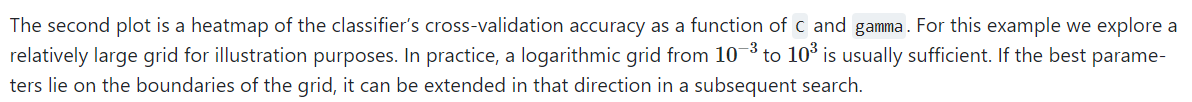

In [27]:
# Train SVM: grid search
#parameters = {'C': np.concatenate((np.arange(0.01, 0.11, 0.01), np.arange(0.2, 1.1, 0.1), np.arange(2, 11, 1))),
 #             'gamma': np.linspace(0.0001, 0.005, 10)
  #           }

C_range = np.logspace(-2, 3, 20)
gamma_range = np.logspace(-9, 3, 20)

In [28]:
gamma_range

array([1.00000000e-09, 4.28133240e-09, 1.83298071e-08, 7.84759970e-08,
       3.35981829e-07, 1.43844989e-06, 6.15848211e-06, 2.63665090e-05,
       1.12883789e-04, 4.83293024e-04, 2.06913808e-03, 8.85866790e-03,
       3.79269019e-02, 1.62377674e-01, 6.95192796e-01, 2.97635144e+00,
       1.27427499e+01, 5.45559478e+01, 2.33572147e+02, 1.00000000e+03])

In [29]:
parameters = {'C': C_range,
              'gamma': gamma_range
             }

# Random search
rs = RandomizedSearchCV(SVC(kernel='rbf'), 
                        parameters, 
                        verbose=2, 
                        cv=4,
                        n_iter=200, 
                        n_jobs=-1
                        )  
rs.fit(X_train, y_train)

# Best model
model = rs.best_estimator_
model.fit(X_train, y_train)

# Look at the scores
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

Fitting 4 folds for each of 200 candidates, totalling 800 fits
0.7314666666666667
0.5536


In [30]:
model = SVC()
model.fit(X_train, y_train)

# Look at the scores
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.5709333333333333
0.5104


In [31]:
# Save
import joblib
np.save('C:/Users/gom39655/sync/code/git/teaching/lectures/03_wise_2021_22/predictive-maintenance/notebooks/examples/evaluation-confusion-matrix-roc/data/spotify_svm_ytest.npy', y_test.values)
np.save('C:/Users/gom39655/sync/code/git/teaching/lectures/03_wise_2021_22/predictive-maintenance/notebooks/examples/evaluation-confusion-matrix-roc/data/spotify_svm_ypredicted.npy', model.predict(X_test))

#### $k$-means

In [32]:
# Maybe the number of generes is insufficient
labels_list = []
inertia_list = []
for n_clusters in range(2, 100, 1):
    print(f'Training k-means with k={n_clusters}')
    clustering = KMeans(n_clusters=n_clusters)
    labels_list.append(clustering.fit_predict(X_train))
    inertia_list.append(clustering.inertia_)

Training k-means with k=2


C:\Programme\Anaconda3\envs\python3115_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Training k-means with k=3
Training k-means with k=4
Training k-means with k=5


C:\Programme\Anaconda3\envs\python3115_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Programme\Anaconda3\envs\python3115_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Programme\Anaconda3\envs\python3115_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Training k-means with k=6
Training k-means with k=7


...

C:\Programme\Anaconda3\envs\python3115_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Training k-means with k=98


C:\Programme\Anaconda3\envs\python3115_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Training k-means with k=99


C:\Programme\Anaconda3\envs\python3115_2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


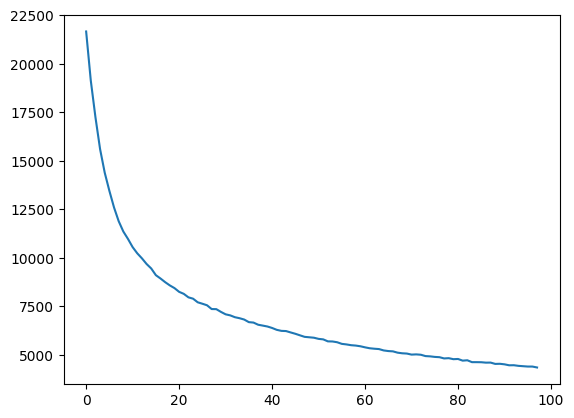

In [33]:
# Look at the scree plot
plt.plot(inertia_list);

# Quellen
<div>
    <img src=attachment:7ac75623-172d-4d2d-8e47-382d3f0fc775.png width=100>
</div>
<div>Icons made by <a href="https://www.flaticon.com/authors/flat-icons" title="Flat Icons">Flat Icons</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>
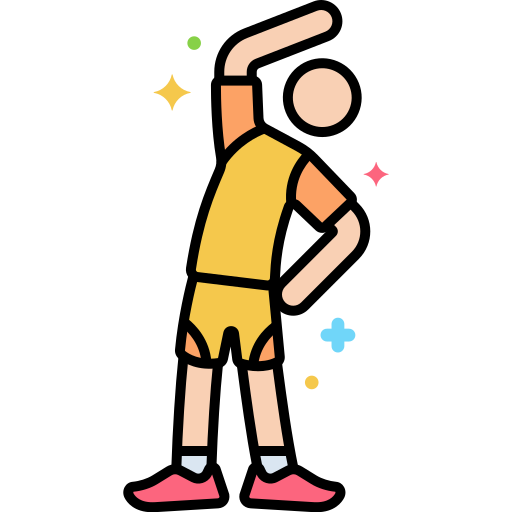